In [1]:
import os
import datetime
import json
import time
import matplotlib.pyplot as plt
import numpy as np

In [75]:
basefolder = 'O:/67203/OnWafMea/DR/Data/2025_05_01_Z_Positioners/Cooldown Logs/' # path of folder with dated log files
allfolders = os.listdir(basefolder) # get the log
logfolders = []
for folder in allfolders:
    if folder[2] == '-' and folder[5] == '-':
        logfolders.append(folder)


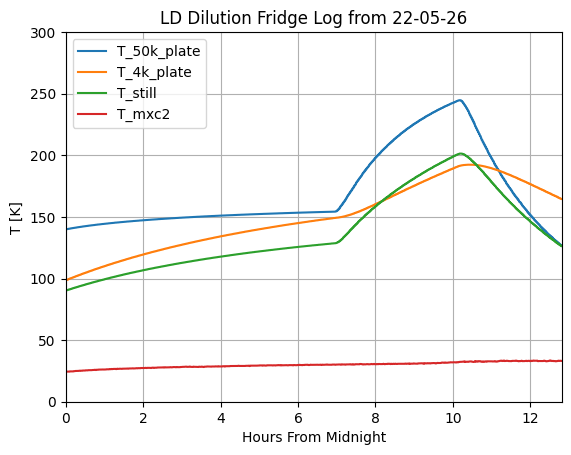

In [132]:
currentlogfolder = logfolders[-1] # -1 index is most recent

f = open(basefolder + '/' + currentlogfolder + '/maxigauge ' + currentlogfolder + '.log')
prawdata = f.read()
f.close()
f = open(basefolder + '/' + currentlogfolder + '/CH1 T ' + currentlogfolder + '.log')
ch1raw = f.read()
f.close()
f = open(basefolder + '/' + currentlogfolder + '/CH2 T ' + currentlogfolder + '.log')
ch2raw = f.read()
f.close()
f = open(basefolder + '/' + currentlogfolder + '/CH5 T ' + currentlogfolder + '.log')
ch5raw = f.read()
f.close()
f = open(basefolder + '/' + currentlogfolder + '/CH6 T ' + currentlogfolder + '.log')
ch6raw = f.read()
f.close()
f = open(basefolder + '/' + currentlogfolder + '/CH7 T ' + currentlogfolder + '.log')
ch7raw = f.read()
f.close()
logjson = {}
logjson['P1'] = []
logjson['P2'] = []
logjson['P3'] = []
logjson['P4'] = []
logjson['P5'] = []
logjson['P6'] = []
logjson['T_50k_plate'] = []
logjson['T_still'] = []
logjson['T_4k_plate'] = []
logjson['T_mxc1'] = []
logjson['T_mxc2'] = []
logjson['date'] = ''
logjson['seconds'] = [] # seconds since midnight
lineindex = 0
for dataline in prawdata.split('\n'):
    if len(dataline) > 0:
        logjson['P1'].append(float(dataline.split(',')[5]))
        logjson['P2'].append(float(dataline.split(',')[11]))
        logjson['P3'].append(float(dataline.split(',')[17]))
        logjson['P4'].append(float(dataline.split(',')[23]))
        logjson['P5'].append(float(dataline.split(',')[29]))
        logjson['P6'].append(float(dataline.split(',')[35]))
        logjson['T_50k_plate'].append(float(ch1raw.split('\n')[lineindex].split(',')[2]))
        logjson['T_still'].append(float(ch2raw.split('\n')[lineindex].split(',')[2]))
        logjson['T_4k_plate'].append(float(ch5raw.split('\n')[lineindex].split(',')[2]))
        #logjson['T_mxc1'].append(float(ch6raw.split('\n')[lineindex].split(',')[2]))
        logjson['T_mxc2'].append(float(ch7raw.split('\n')[lineindex].split(',')[2]))
 
        logjson['date'] = dataline.split(',')[0]
        timestring = dataline.split(',')[1]  
        h, m, s = timestring.split(':')
        logjson['seconds'].append(int(h) * 3600 + int(m) * 60 + int(s))
        lineindex += 1
file_object = open("data/log.json", "w")
file_object.write(json.dumps(logjson))
file_object.close()

T_50k_plate = np.array(logjson['T_50k_plate'])
T_4k_plate = np.array(logjson['T_4k_plate'])
T_still = np.array(logjson['T_still'])
T_mxc2 = np.array(logjson['T_mxc2'])

seconds = np.array(logjson['seconds'])
T50k = np.array(logjson['T_still'])


plt.plot(seconds/3600,T_50k_plate)
plt.plot(seconds/3600,T_4k_plate)
plt.plot(seconds/3600,T_still)
plt.plot(seconds/3600,T_mxc2)
plt.grid()
plt.ylim([0,300])
plt.xlim([0,seconds[-1]/3600])
plt.xlabel('Hours From Midnight')
plt.ylabel('T [K]')
plt.legend(['T_50k_plate','T_4k_plate','T_still','T_mxc2'])
plt.title('LD Dilution Fridge Log from ' + logjson['date'])
plt.savefig('plots/temperatures_' + currentlogfolder +'.png')


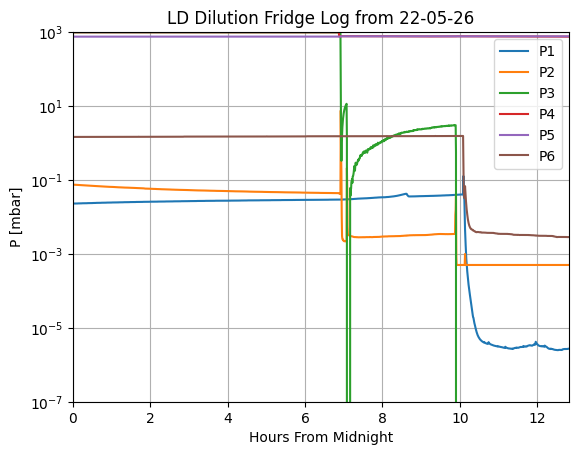

In [133]:
plt.semilogy(seconds/3600,np.array(logjson['P1']))
plt.semilogy(seconds/3600,np.array(logjson['P2']))
plt.semilogy(seconds/3600,np.array(logjson['P3']))
plt.semilogy(seconds/3600,np.array(logjson['P4']))
plt.semilogy(seconds/3600,np.array(logjson['P5']))
plt.semilogy(seconds/3600,np.array(logjson['P6']))

plt.grid()
plt.ylim([1e-7,1e3])
plt.xlim([0,seconds[-1]/3600])
plt.xlabel('Hours From Midnight')
plt.ylabel('P [mbar]')
plt.legend(['P1','P2','P3','P4','P5','P6'])

plt.title('LD Dilution Fridge Log from ' + logjson['date'])
plt.savefig('plots/pressures_' + currentlogfolder +'.png')


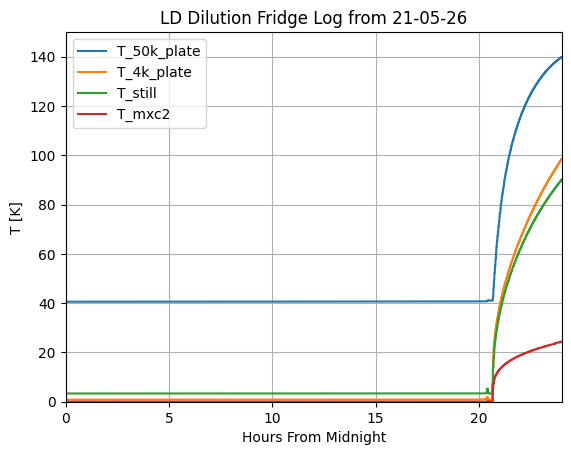

In [130]:
currentlogfolder = logfolders[-2] # -1 index is most recent

f = open(basefolder + '/' + currentlogfolder + '/maxigauge ' + currentlogfolder + '.log')
prawdata = f.read()
f.close()
f = open(basefolder + '/' + currentlogfolder + '/CH1 T ' + currentlogfolder + '.log')
ch1raw = f.read()
f.close()
f = open(basefolder + '/' + currentlogfolder + '/CH2 T ' + currentlogfolder + '.log')
ch2raw = f.read()
f.close()
f = open(basefolder + '/' + currentlogfolder + '/CH5 T ' + currentlogfolder + '.log')
ch5raw = f.read()
f.close()
f = open(basefolder + '/' + currentlogfolder + '/CH6 T ' + currentlogfolder + '.log')
ch6raw = f.read()
f.close()
f = open(basefolder + '/' + currentlogfolder + '/CH7 T ' + currentlogfolder + '.log')
ch7raw = f.read()
f.close()
logjson = {}
logjson['P1'] = []
logjson['P2'] = []
logjson['P3'] = []
logjson['P4'] = []
logjson['P5'] = []
logjson['P6'] = []
logjson['T_50k_plate'] = []
logjson['T_still'] = []
logjson['T_4k_plate'] = []
logjson['T_mxc1'] = []
logjson['T_mxc2'] = []
logjson['date'] = ''
logjson['seconds'] = [] # seconds since midnight
lineindex = 0
for dataline in prawdata.split('\n'):
    if len(dataline) > 0:
        logjson['P1'].append(float(dataline.split(',')[5]))
        logjson['P2'].append(float(dataline.split(',')[11]))
        logjson['P3'].append(float(dataline.split(',')[17]))
        logjson['P4'].append(float(dataline.split(',')[23]))
        logjson['P5'].append(float(dataline.split(',')[29]))
        logjson['P6'].append(float(dataline.split(',')[35]))
        logjson['T_50k_plate'].append(float(ch1raw.split('\n')[lineindex].split(',')[2]))
        logjson['T_still'].append(float(ch2raw.split('\n')[lineindex].split(',')[2]))
        logjson['T_4k_plate'].append(float(ch5raw.split('\n')[lineindex].split(',')[2]))
        #logjson['T_mxc1'].append(float(ch6raw.split('\n')[lineindex].split(',')[2]))
        logjson['T_mxc2'].append(float(ch7raw.split('\n')[lineindex].split(',')[2]))
 
        logjson['date'] = dataline.split(',')[0]
        timestring = dataline.split(',')[1]  
        h, m, s = timestring.split(':')
        logjson['seconds'].append(int(h) * 3600 + int(m) * 60 + int(s))
        lineindex += 1
file_object = open("data/log.json", "w")
file_object.write(json.dumps(logjson))
file_object.close()

T_50k_plate = np.array(logjson['T_50k_plate'])
T_4k_plate = np.array(logjson['T_4k_plate'])
T_still = np.array(logjson['T_still'])
T_mxc2 = np.array(logjson['T_mxc2'])

seconds = np.array(logjson['seconds'])
T50k = np.array(logjson['T_still'])


plt.plot(seconds/3600,T_50k_plate)
plt.plot(seconds/3600,T_4k_plate)
plt.plot(seconds/3600,T_still)
plt.plot(seconds/3600,T_mxc2)
plt.grid()
plt.ylim([0,150])
plt.xlim([0,seconds[-1]/3600])
plt.xlabel('Hours From Midnight')
plt.ylabel('T [K]')
plt.legend(['T_50k_plate','T_4k_plate','T_still','T_mxc2'])
plt.title('LD Dilution Fridge Log from ' + logjson['date'])
plt.savefig('plots/temperatures_' + currentlogfolder +'.png')


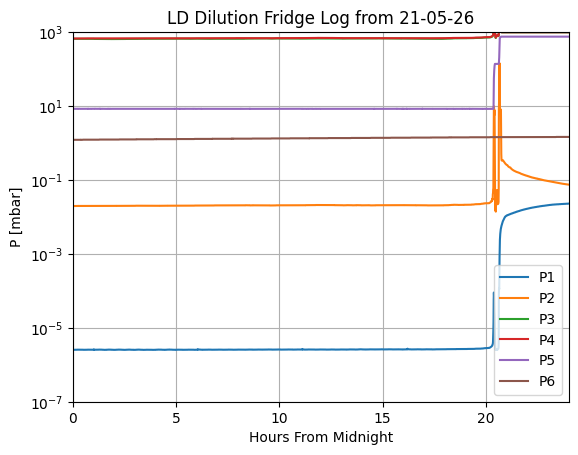

In [131]:
plt.semilogy(seconds/3600,np.array(logjson['P1']))
plt.semilogy(seconds/3600,np.array(logjson['P2']))
plt.semilogy(seconds/3600,np.array(logjson['P3']))
plt.semilogy(seconds/3600,np.array(logjson['P4']))
plt.semilogy(seconds/3600,np.array(logjson['P5']))
plt.semilogy(seconds/3600,np.array(logjson['P6']))

plt.grid()
plt.ylim([1e-7,1e3])
plt.xlim([0,seconds[-1]/3600])
plt.xlabel('Hours From Midnight')
plt.ylabel('P [mbar]')
plt.legend(['P1','P2','P3','P4','P5','P6'])

plt.title('LD Dilution Fridge Log from ' + logjson['date'])
plt.savefig('plots/pressures_' + currentlogfolder +'.png')
